# Práctica 3: Clustering

Nas próximas prácticas imos centrarnos nunha das técnicas máis comúns e amplamente coñecidas da aprendizaxe non supervisada: o agrupamento ou *clustering*.

Dentro do *clustering* existen diversos tipos de algoritmos, dos cales nos centraremos en 4 grupos principais, dedicándolle unha sesión a cada un. En concreto, esta é a planificación que imos seguir:

- **Práctica 3.1**: Clustering particional
- **Práctica 3.2**: Clustering xerárquico
    - *Avaliación Prácticas 3.1 e 3.2*
- **Práctica 3.3**: Clustering baseado en densidade: *DBSCAN*
- **Práctica 3.4**: Clustering gaussiano
    - *Avaliación Prácticas 3.3 e 3.4*

# Práctica 3.1: Clustering particional

---

**Asignatura:** Aprendizaxe Automática Non Supervisada --- *Universidade de Santiago de Compostela*

**Profesor:** Pedro Gamallo Fernández

**Email:** pedro.gamallo.fernández@usc.es

**Curso:** 2024-2025

---


*Entrega de*:

<center><h3>LUCAS ANDREA MARTINEZ CALVEIRO</h3></center>

## Instrucións da práctica

Ao igual que no resto de prácticas da asignatura, nesta sesión empregaremos un **Jupyter Notebook** que servirá como guión para a realización da práctica. 

O **Jupyter Notebook** é un arquivo *Markdown* que integra celdas de código Python, as cales deberedes completar e executar paso a paso seguindo as indicacións do enunciado.

O *notebook* execútase sobre un *kernel* de Python que garda unha **memoria das celdas executadas**. Desta forma, as funcións definidas nunha celda previamente executada poden volver a empregarse en sucesivas celdas sen necesidade de redefinila de cada vez. Pero OLLO, se nos esquecemos de executar a celda na que se define unha función e intentamos empregala máis adiante, recibiremos un erro.

Ao rematar a práctica, deberedes exportar o guión completo a formato HTML, e subilo ao campus virtual co nome ``APELIDO1_APELIDO2_NOME_ClusteringParticional.html``. Lembrade tamén **inidicar o voso nome na celda anterior**.

## Reproducibilidade dos resultados

Moitas das funcións que empregaremos fan uso de inicializacións mediante o uso de números aleatorios. Debido a isto, ao executar diversas veces o mesmo código, imos obter resultados diferentes, facendo bastante complicada a depuración do código.

Para evitar isto, imos fixar unha semente (*seed*) antes da execución de cada función que introduza un compoñente aleatorio, ou nos propios parámetros da función, se esta o permite. Para obter todos os mesmos resultados, imos empregar sempre o valor ``123``.

In [34]:
import numpy as np

SEED = 123
np.random.seed(SEED)

## Introdución

Nesta práctica imos centrarnos nas técnicas de *clustering* particional, e concretamente nos algortimos **k-means** e **k-medoids**.

Comezaremos implementando as funcións básicas do algoritmo **k-means** e veremos a súa aplicación sobre o dataset ``iris``, un conxunto de datos sobre flores amplamente coñecido e empregado na aprendizaxe automática.

A continuación deberedes modificar as funcións para adaptalas ao algoritmo **k-medoids**, observando as diferencias nos *clusters* xerados.

Por último, analizaremos os distintos hiperparámetros que inflúen no algoritmo de agrupamento fancedo uso da implementación de  ``KMeans`` existente na libraría ``scikit-learn`` sobre un dataset con datos sobre países.

## Lectura e análise do dataset Iris

Para ler e analizar os datos faremos uso da libraría `pandas`, que nos permite almacenar os datos nun formato tabular chamado *DataFrame*.

Cargamos o dataset coa función `read_csv()`:

In [35]:
import pandas as pd 

iris_df = pd.read_csv('iris.csv')
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


Como podemos ver, o conxunto de datos conta con 150 mostras (filas) con 4 variables númericas (columnas `sepal_length`, `sepal_width`, `petal_length` e `petal_width`) e 1 variable categórica (`species`). 

A columna `species` identifica a clase de flor á que pertence cada observación. Co código seguinte podemos ver cantas clases distintas existen no conxunto de datos, e cantas observacións se corresponden con cada clase:

In [36]:
iris_df['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Como estamos nun paradigma non supervisado, obviaremos a columna `species` á hora de utilizar os algoritmos de clustering, empregándoa só para comparar os clusters resultantes cos valores das clases orixinais.

## Implementación das funcións de *K-Means*

*K-means* é o algoritmo de clustering particional máis amplamente coñecido e empregado. O $k$ do seu nome fai alusión ao número $k$ de *clusters* ou grupos resultantes, sendo este un hiperparámetro do algoritmo que debe ser fixado a man. O agrupamento realízase minimizando a suma de distancias (habitualmente distancia cadrática) entre cada exemplo e o centroide do grupo ao que foi asignado. 

O algoritmo consta de 3 etapas diferenciadas:

1. **Inicialización**: unha vez escollido o número de grupos $k$, establécense aleatoriamente $k$ centroides no espazo de datos.
2. **Asignación dos exemplos aos centroides**: cada mostra do dataset é asignada ao seu centroide máis próximo.
3. **Actualización dos centroides**: para cada grupo, actualízase a posición do centroide tomando como novo centroide a posición media dos exemplos pertenecentes a dito grupo.
 
Os pasos 2 e 3 repítense durante $n$ iteracións. O algoritmo resolve un problema de optimización, sendo a función a optimizar (minimizar) a suma das distancias cadráticas de cada exemplo ao centroide do seu cluster.
 
Para implementar o algoritmo, imos empregar as seguintes funcións:

In [37]:
# Función de distancia cadrática
def calcula_distancias(a, b):
    # Xeramos unha matriz para almacenar a distancia de cada punto do conxunto 'a' (filas) a todos os do conxunto 'b' (columnas)
    matriz_distancias = np.empty([a.shape[0], b.shape[0]])
    # Calculamos a distancia punto a punto dos conxuntos a e b
    for i in range(a.shape[0]):
        for j in range(b.shape[0]):
            dist = a[i] - b[j]
            matriz_distancias[i, j] = dist[0] ** 2 + dist[1] ** 2
    
    return matriz_distancias

# Función de custo a optimizar
def loss_func(x, centroides, clusters):
    # Obtemos a distancia de cada punto ao seu cluster
    distancias = x - centroides[clusters]
    # Calculamos o custo
    custo = 1.0/x.shape[0] * sum((np.sqrt(distancias[:, 0]**2 + distancias[:,1]**2))**2)
    return custo

# Función de actualización de centroides
def actualiza_centr(x, clusters, centroides):
    for i in range(centroides.shape[0]):
        x_cluster_i = x[clusters==i]
        centroides[i] = np.sum(x_cluster_i, axis=0)/x_cluster_i.shape[0]
    
    return centroides

# Función de clustering k-means
def k_medias(x, centroides_iniciais, iteracions):
    hist_clusters = []
    hist_centroides = []
    hist_custo = []
    
    # Paso 1: Asignación de centroides iniciais
    centroides = centroides_iniciais.copy()
    for i in range(iteracions):
        # Paso 2: Asignación de mostras ao centroide máis cercano
        dist_centroides = calcula_distancias(x, centroides)
        clusters = np.argmin(dist_centroides, axis=1)
        # Paso 3: Actualización dos centroides
        centroides = actualiza_centr(x, clusters, centroides)
        custo = loss_func(x, centroides, clusters)
        # Gardamos o historial de cada iteración
        hist_clusters.append(clusters.copy())
        hist_centroides.append(centroides.copy())
        hist_custo.append(custo.copy())
    
    return {'custo': hist_custo, 'clusters': hist_clusters, 'centroides': hist_centroides}

Agora podemos executar o primeiro agrupamento. Para iso, como comentamos anteriormente, imos quedarnos só cos valores das 4 columnas numéricas, obviando a columna `species`.

In [38]:
iris_values = iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
iris_values

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

O primeiro paso é definir os centroides iniciais. Como xa sabemos que existen 3 especies, imos definir 3 grupos por simplicidade. Polo tanto, definimos 3 centroides aleatorios:

In [39]:
n_clusters = 3

np.random.seed(SEED) # Indicamos a semente de novo para asegurar a replicabilidade dos resultados

centr_iniciais = iris_values[np.random.choice(iris_values.shape[0], size=n_clusters, replace=False)]
centr_iniciais

array([[6.3, 2.5, 4.9, 1.5],
       [6.8, 3. , 5.5, 2.1],
       [6.4, 2.8, 5.6, 2.2]])

Aplicamos o algoritmo de clustering durante 10 iteracións:

In [40]:
n_iter = 5

agrupamento_1 = k_medias(iris_values, centr_iniciais, n_iter)

A variable `agrupamento_1` almacena o historial de custos, os centroides e as asignacións de cada exemplo aos 3 clusters en todas as iteracións. Por exemplo, imos comprobar os centroides nas iteracións 3 e 5:

In [41]:
agrupamento_1['centroides'][2] # Recordade que se comeza a contar en 0

array([[5.25882353, 2.75098039, 3.17647059, 0.92941176],
       [6.75283019, 3.01132075, 5.40188679, 1.89433962],
       [5.44347826, 3.43913043, 2.51086957, 0.69565217]])

In [42]:
agrupamento_1['centroides'][n_iter-1]

array([[5.34583333, 2.73125   , 3.45416667, 1.05208333],
       [6.64920635, 2.98730159, 5.3015873 , 1.84126984],
       [5.15384615, 3.55897436, 1.64102564, 0.34102564]])

Podemos ver tamén como variou a asignación de cluster ás 5 primeiras observacións do dataset nas iteracións 1, 3 e 5:

In [43]:
agrupamento_1['clusters'][0][:10]

array([2, 0, 0, 0, 2, 2, 2, 2, 0, 0])

In [44]:
agrupamento_1['clusters'][2][:10]

array([2, 0, 0, 0, 2, 2, 0, 2, 0, 0])

In [45]:
agrupamento_1['clusters'][n_iter-1][:10]

array([2, 0, 2, 0, 2, 2, 2, 2, 0, 0])

Imos debuxar unha gráfica coa evolución do custo, para observar como foi converxendo o algoritmo ao longo das iteracións. Para iso, empregaremos a libraría `matplotlib`:

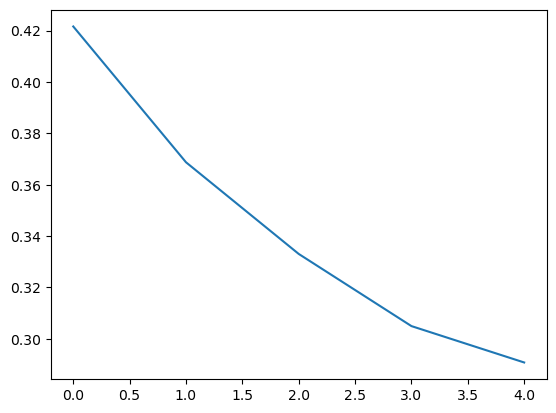

In [46]:
import matplotlib.pyplot as plt

plt.plot(agrupamento_1['custo'])
plt.show()

Por último, imos representar gráficamente os clusters resultantes da última iteración. Como as nosas mostras teñen 4 variables, imos empregar unha técnica de redución da dimensionalidade (`PCA`) para poder representalas como puntos en 2-D. Tamén imos representar as clases orixinais de cada mostra para comparar:

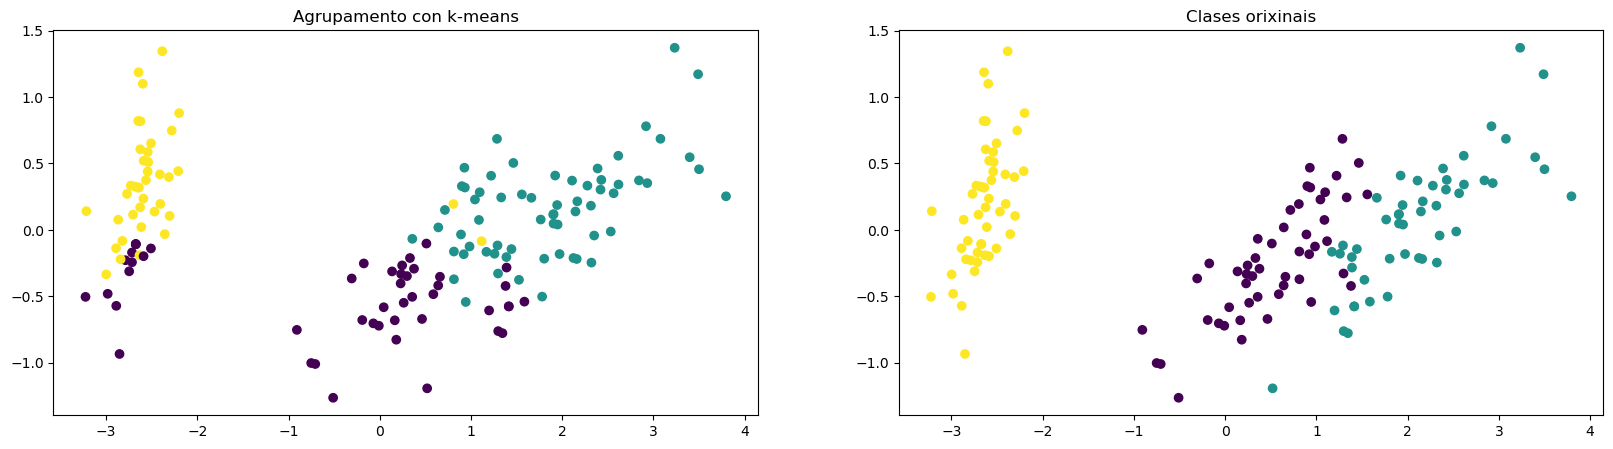

In [47]:
from sklearn.decomposition import PCA

def plot_clusters(data, clusters, classes):
    fig = plt.figure(figsize=(20, 5))  # Creamos unha figura (contenedor para elementos a debuxar)
    ax1 = fig.add_subplot(121, projection='rectilinear')  # Engadimos 2 eixos, xa que imos representar dúas gráficas
    ax2 = fig.add_subplot(122, projection='rectilinear')

    ax1.set_title("Agrupamento con k-means")
    ax1.scatter(data[:, 0], data[:, 1], c=clusters)

    ax2.set_title("Clases orixinais")
    ax2.scatter(data[:, 0], data[:, 1], c=classes)

    plt.show()

# Reducimos a dimensionalidade dos datos con PCA
iris_reduced = PCA(n_components=2, random_state=SEED).fit_transform(iris_values) # Fixamos o seed para reproducir os resultados

# Mapeamos as especies a números para poder pintalos coma cores
species_color = {'Iris-versicolor': 0, 'Iris-virginica': 1, 'Iris-setosa': 2}
species = iris_df['species'].map(species_color)

# Imprimimos as gráficas
plot_clusters(iris_reduced, agrupamento_1['clusters'][n_iter-1], species)

Como se pode ver, o algoritmo realiza un agrupamento similar ás clases orixinais, aínda que todavía agrupa de maneira errónea certas mostras, especialmente aquelas cercanas ás fronteiras das clases.

Probade a executar de novo o algoritmo aumentando o número de iteracións (por exemplo, a **10 iteracións**) e representade novamente as gráficas para ver como varía. Para manter a reproducibilidade, empregade os mesmos centroides iniciais e o resultado da `PCA` de antes:

In [48]:
# K-MEANS CON 10 ITERACIÓNS
n_iter = 10

agrupamento_2 = k_medias(iris_values, centr_iniciais, n_iter)

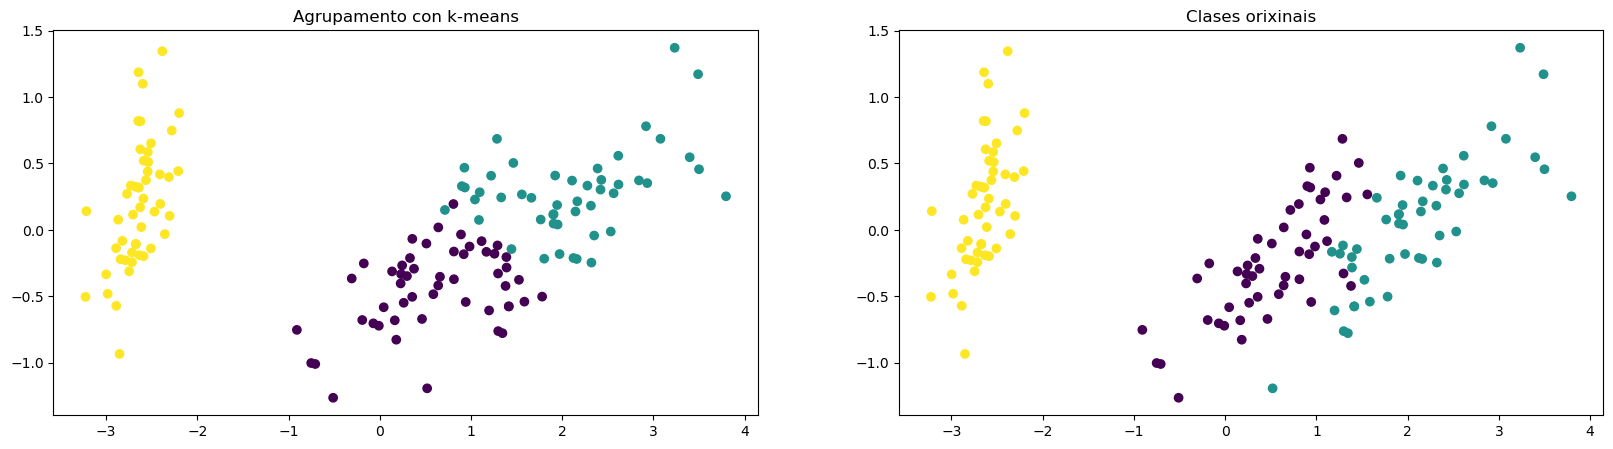

In [49]:
plot_clusters(iris_reduced, agrupamento_2['clusters'][n_iter-1], species)

## Implementación do *k-medians*

A diferenza de *k-means*, que selecciona como centroides o valor medio dos compoñentes de cada grupo (o cal pode resultar sensible á presenza de *outliers*), o algoritmo *k-medoids* emprega un valor real correspondente a un dos elementos do cluster: o *medoid*. O *medoid* correspóndese coa mostra dentro do cluster que minimiza a distancia co resto de mostras do mesmo cluster. De tal forma, pódese entender o *medoid* como o punto (real) medio do cluster.

O algoritmo, polo tanto, pode definirse cos seguintes 3 pasos:

1. **Inicialización**: unha vez escollido o número de grupos $k$, establécense aleatoriamente $k$ mostras do conxunto de datos como *medoids*.
2. **Asignación dos exemplos aos medoids**: cada mostra do dataset é asignada ao seu *medoid* máis próximo.
3. **Actualización dos *medoids***: para cada grupo, actualízase a posición do *medoid* tomando como novo valor a mostra de dito grupo que minimiza a distancia co resto de mostras.

Partindo das funcións empregadas no caso do algoritmo *k-means*, completade o código seguinte de acordo co algoritmo *k-medoids*: 

In [50]:
# Función de distancia cuadrática
def calcula_distancias(a, b):
    # Xeramos unha matriz para almacenar a distancia de cada punto do conxunto 'a' (filas) a todos os do conxunto 'b' (columnas)
    matriz_distancias = np.empty([a.shape[0], b.shape[0]])
    for i in range(a.shape[0]):
        for j in range(b.shape[0]):
            dist = a[i] - b[j]
            matriz_distancias[i, j] = dist[0] ** 2 + dist[1] ** 2
    return matriz_distancias

# Función de custo a optimizar
def loss_func(x, medoides, clusters):
    custo = 0.0
    for i, medoid in enumerate(medoides):
        x_cluster_i = x[clusters == i]
        distancias = np.sqrt(np.sum((x_cluster_i - medoid)**2, axis=1))
        custo += np.sum(distancias)
    return custo

# Función para actualizar medoides
def actualiza_medoides(x, clusters, medoides):
    for i in range(medoides.shape[0]):
        x_cluster_i = x[clusters == i]
        # Evitar clusters vacíos
        if len(x_cluster_i) > 0: 
            # Distancia de todos contra todos en el mismo cluster
            distancias = calcula_distancias(x_cluster_i, x_cluster_i)
            # Suma de las distancias para cada punto
            suma_distancias = np.sum(distancias, axis=1)
            # El nuevo medoide es el índice que minimiza esa suma
            idx_min = np.argmin(suma_distancias)
            medoides[i] = x_cluster_i[idx_min]
    return medoides

# Algoritmo de clustering k-medoids
def k_medoides(x, medoides_iniciais, iteraciones):
    hist_clusters = []
    hist_medoides = []
    hist_custo = []

    # Paso 1: Asignación de centroides iniciais
    medoides = medoides_iniciais.copy()
    for i in range(iteraciones):
        # Paso 2: Asignación de puntos aos medoides máis próximos
        distancias = calcula_distancias(x, medoides)
        clusters = np.argmin(distancias, axis=1)
        
        # Paso 3: Actualización dos medoides
        medoides = actualiza_medoides(x, clusters, medoides)
        
        # Cálculo do custo
        custo = loss_func(x, medoides, clusters)
        
        # Guardar historial
        hist_clusters.append(clusters.copy())
        hist_medoides.append(medoides.copy())
        hist_custo.append(custo)

    return {'custo': hist_custo, 'clusters': hist_clusters, 'medoides': hist_medoides}

Definimos 3 mostras do conxunto de datos como *medoids*:

In [51]:
n_clusters = 3

np.random.seed(SEED) # Indicamos a semente de novo para asegurar a replicabilidade dos resultados

centr_iniciais = iris_values[np.random.choice(iris_values.shape[0], size=n_clusters, replace=False)]
centr_iniciais

array([[6.3, 2.5, 4.9, 1.5],
       [6.8, 3. , 5.5, 2.1],
       [6.4, 2.8, 5.6, 2.2]])

Executamos o algoritmo durante 5 iteracións:

In [52]:
n_iter = 5

agrupamento_3 = k_medoides(iris_values, centr_iniciais, n_iter)

Imprimimos os resultados e comparamos de novo coas clases orixinais:

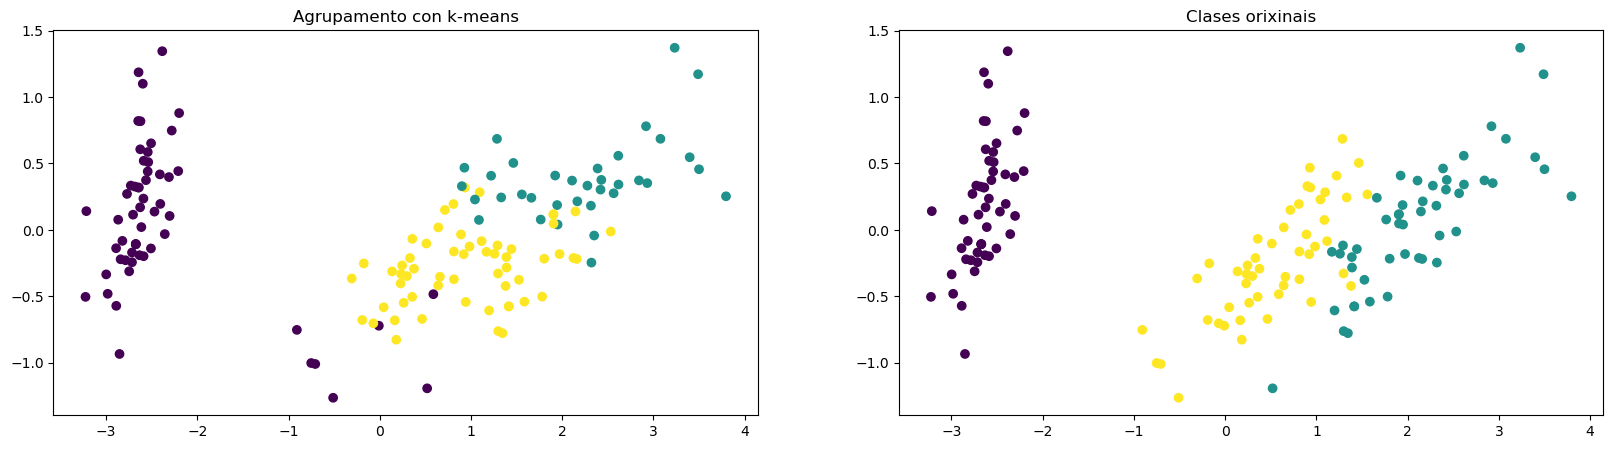

In [53]:
# Imprimimos as gráficas
species_color = {'Iris-setosa': 0, 'Iris-virginica': 1, 'Iris-versicolor': 2}
species = iris_df['species'].map(species_color)

plot_clusters(iris_reduced, agrupamento_3['clusters'][n_iter-1], species)

## Optimización de hiperparámetros

Os algoritmos de clustering como os que acabamos de ver presentan unha serie de parámetros axustables a man, coñecidos como hiperparámetros: número de clusters, centroides iniciais, número de iteracións...

A continuación imos analizar como a selección de distintos valores para estes hiperparámetros pode influír notablemente nos agrupamentos obtidos. Por simplicidade, empregaremos a implementación de `KMeans` dispoñible en `scikit-learn`. Podedes consultar máis información sobre esta implementación e as súas función na [documentación oficial da libraría](https://scikit-learn.org/1.5/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans).

Neste caso, ademais, empregaremos o dataset `country-data`, que contén información sobre diferentes países do mundo: 

In [54]:
country_df = pd.read_csv('country-data.csv')
country_df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
158,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
159,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
160,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
161,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


De novo, non empregaremos a columna categórica que representa o nome do país:

In [55]:
country_values = country_df.loc[:, country_df.columns != 'country']
country_values

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
158,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
159,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
160,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
161,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


A continuación tedes un exemplo de uso da función de `KMeans` de `scikit-learn`, que poderedes usar de base para o resto de exercicios:

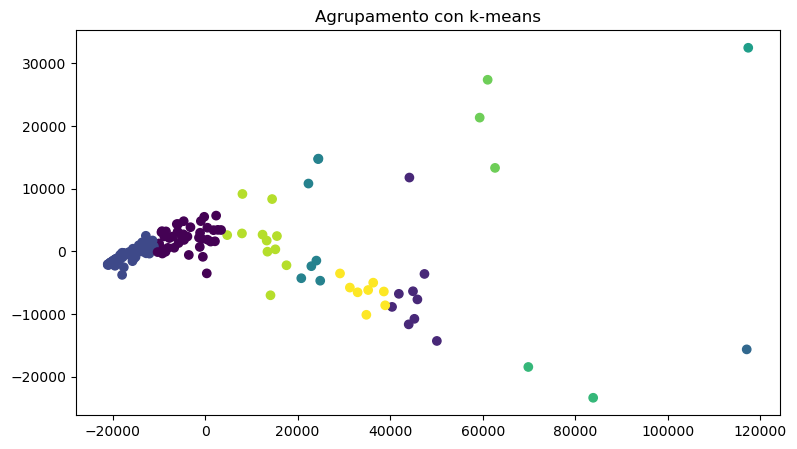

In [56]:
from sklearn.cluster import KMeans

def plot_clusters_(data, clusters):
    fig = plt.figure(figsize=(20, 5))  # Creamos unha figura (contenedor para elementos a debuxar)
    ax1 = fig.add_subplot(121, projection='rectilinear')

    ax1.set_title("Agrupamento con k-means")
    ax1.scatter(data[:, 0], data[:, 1], c=clusters)

    plt.show()
    
# Reducimos a dimensionalidade dos datos con PCA
country_reduced = PCA(n_components=2, random_state=SEED).fit_transform(country_values) # Fixamos o seed para reproducir os resultados

kmeans = KMeans(n_clusters=10, init='k-means++', max_iter=50, n_init=1, random_state=SEED) # Mantede os mesmos valores de atributos, modificando unicamente aquel que se vos pida probar en cada caso
predicted_clusters = kmeans.fit_predict(country_values)
plot_clusters_(country_reduced, predicted_clusters)

### Selección do número de clusters

Un dos principais problemas nos algoritmos de clustering e a selección do número $k$ de clusters cando non se ten coñecemento previo sobre o conxunto de datos. A selección do $k$ óptimo é a miúdo ambigua, con interpretacións que dependen da forma e a escala da distribución de puntos no conxunto de datos. Aumentar o $k$ sen penalización sempre reducirá o valor do custo na agrupación resultante, ata o caso extremo de custo cero se cada punto dos datos se considera como o seu propio agrupamento (é decir, cando $k$ é igual ao número de exemplos do conxunto de datos). Intuitivamente, a elección óptima de $k$ acadará un equilibrio entre a compresión máxima dos datos utilizando un só cluster e a máxima precisión ao asignar cada instancia ao seu cluster propio. 

Cando o valor apropiado de $k$ non é evidente a partir do coñecemento previo das propiedades do conxunto de datos, existen métodos que nos axudan a tomar esta decisión. Un dos máis sinxelos é o **método do cóbado** (en inglés, *elbow method*), o cal analiza a redución do custo en función do número de clusters: debe elixirse aquel número de clusters tal que, ao agregar outro cluster máis non se acaden resultados moito mellores. Dun xeito máis formal, se se grafica o custo obtido en función de $k$, os primeiros agrupamentos terán un alto erro por agrupar moitos datos en poucos clusters, pero nalgún momento a ganancia marxinal caerá, provocando un "cóbado" no gráfico. O número de clusters fíxase a este punto, de ahí o nome do método.

Probade diferentes números de clusters, **dende 5 ata 50, con incrementos de 5 en 5**, e descubride cal é o valor máis axeitado mediante o método do cóbado:

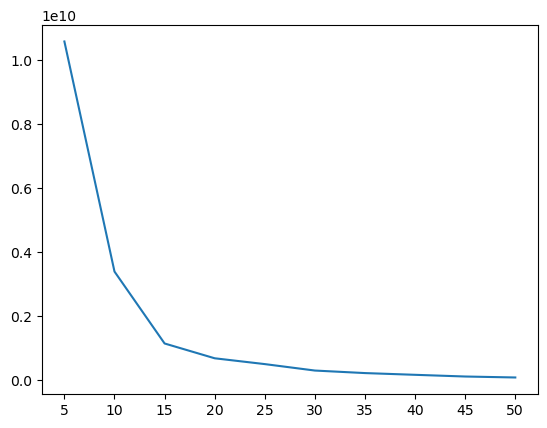

5

In [57]:
kmeans_losses = []

# COMPLETADE O CÓDIGO, PROBANDO DIFERENTE NÚMEROS DE CLUSTERS DE 5 A 50 CON INCREMENTOS DE 5 (5, 10, 15, ..., 50)
n_clusters_list = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
for n_clusters in n_clusters_list:
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=50, n_init=1, random_state=SEED)
    kmeans.fit(country_values)
    kmeans_losses.append(kmeans.inertia_)  # Atributo que almacena o custo do modelo

# Imprimimos o custo con cada número de clusters
plt.plot(kmeans_losses)
plt.xticks(range(len(kmeans_losses)), n_clusters_list) # Para axustar o eixo X aos valores correctos
plt.show()

# vemos el k optimo con el método del codo 
k_optimo = n_clusters_list[np.argmin(np.diff(kmeans_losses))]
k_optimo

### Inicializacións dos centroides

A selección dos centroides iniciais é outro dos factores que máis afectan á converxencia do algoritmo. A implementación de `scikit-learn` permite diferentes estratexias para realizar dita inicialización. No exemplo anterior xa empregamos a opción `k-means++`. Outra opción é a inicialización aleatoria, como xa vimos anteriormente. Cando se usa esta estratexia, unha opción común é realizar diversas inicializacións quedándose finalmente coa que devolve un mellor resultado. A función `KMeans` xa nos permite controlar todo isto a través dos seus parámetros.

Lede a dcumentación da implementación de `scikit-learn` e probade a inicialización aleatoria de centroides, modificando o número de inicializacións **entre 10 e 100, con incrementos de 10 en 10**. Novamente, analizade que opción é mellor empregando o método do cóbado:

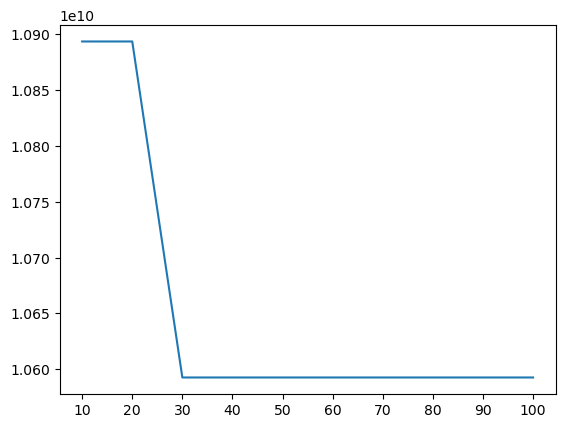

In [60]:
kmeans_losses = []
n_inits = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

for n_init in n_inits:
    # Usamos k=5 (tu valor óptimo) e init='random'
    kmeans = KMeans(n_clusters=5, init='random', max_iter=50, n_init=n_init, random_state=SEED)
    kmeans.fit(country_values)
    kmeans_losses.append(kmeans.inertia_)  

# Imprimimos o custo con cada número de clusters
plt.plot(kmeans_losses)
plt.xticks(range(len(kmeans_losses)), n_inits) # Para axustar o eixo X aos valores correctos
plt.show()